# LLM Performance 2025-2026: Frontier Model Analysis
## A Comprehensive Study of Benchmarks, Pricing, and Model Performance
**Introduction** 
* The AI landscape is currently defined by a "Benchmark War" where speed, cost-efficiency, and reasoning capabilities are as critical as raw intelligence. This notebook performs a deep dive into a dataset covering 24 frontier large language models (LLMs) released between 2024 and 2026.
Our analysis spans major global players including OpenAI, Google DeepMind, Anthropic, Meta, and DeepSeek. We aim to move beyond simple rankings to understand the underlying trade-offs between a model's architectural specs (like context windows) and its real-world performance in coding, mathematics, and professional-level reasoning.
* Author-Shravan Padhar
* Date - 3 March 2026

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
import pandas as pd
import os
path = kagglehub.dataset_download("alitaqishah/llm-benchmark-wars-2025-2026-24-models-compared")

csv_path = os.path.join(path, 'llm_benchmark_comparison_2025_2026.csv')
df = pd.read_csv(csv_path)
df.head()

,rank,model_name,organization,country,release_year,release_month,type,architecture,modality,open_source,...,latency_s,reasoning_model,multimodal,best_for,license,overall_benchmark_avg,performance_per_dollar,speed_tier,price_tier,context_tier
0,1,GPT-5.2,OpenAI,USA,2025,9,Proprietary,Transformer,Multimodal,False,...,0.85,False,True,"Speed, real-time apps, chatbots",Proprietary,90.30,53.41,Fast,Mid-range,Large
1,2,GPT-5.3 Codex,OpenAI,USA,2025,11,Proprietary,Transformer,Text+Code,False,...,1.10,True,False,"Code generation, software engineering",Proprietary,88.62,31.64,Medium,Mid-range,Extended
2,3,Gemini 3.1 Pro,Google DeepMind,USA,2025,10,Proprietary,Transformer,Multimodal,False,...,0.72,False,True,"Long context, multimodal, GPQA leader",Proprietary,90.22,73.81,Medium,Mid-range,Massive
3,4,Claude Opus 4.6,Anthropic,USA,2025,8,Proprietary,Transformer,Multimodal,False,...,1.50,False,True,"Coding, reasoning, lowest hallucination rate",Proprietary,89.60,6.21,Medium,Premium,Extended
4,5,Claude Opus 4.5,Anthropic,USA,2025,5,Proprietary,Transformer,Multimodal,False,...,1.60,False,True,"SWE-bench leader, production code",Proprietary,88.82,6.14,Medium,Premium,Extended


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rank                    24 non-null     int64  
 1   model_name              24 non-null     object 
 2   organization            24 non-null     object 
 3   country                 24 non-null     object 
 4   release_year            24 non-null     int64  
 5   release_month           24 non-null     int64  
 6   type                    24 non-null     object 
 7   architecture            24 non-null     object 
 8   modality                24 non-null     object 
 9   open_source             24 non-null     bool   
 10  parameters_b            10 non-null     float64
 11  context_window_k        24 non-null     int64  
 12  input_price_per_1m      24 non-null     float64
 13  output_price_per_1m     24 non-null     float64
 14  mmlu                    24 non-null     floa

In [4]:
df.describe()

,rank,release_year,release_month,parameters_b,context_window_k,input_price_per_1m,output_price_per_1m,mmlu,humaneval,gpqa_diamond,swe_bench,hellaswag,aime_2025,speed_tok_s,latency_s,overall_benchmark_avg,performance_per_dollar
count,24.000000,24.000000,24.000000,10.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,12.500000,2024.916667,6.125000,215.000000,832.666667,2.556875,12.041667,87.104167,90.008333,73.275000,61.720833,95.333333,78.950000,136.166667,0.736250,78.025833,1380.434167
std,7.071068,0.282330,2.802367,265.809038,2031.795836,4.367049,21.329776,5.814785,6.320836,16.203898,18.272930,2.919599,18.550495,91.828132,0.638264,11.096513,2925.126831
min,1.000000,2024.000000,1.000000,4.000000,32.000000,0.000000,0.000000,68.200000,70.100000,35.400000,18.200000,85.300000,28.400000,38.000000,0.180000,47.980000,6.140000
25%,6.750000,2025.000000,4.000000,34.000000,128.000000,0.131250,0.390000,86.225000,88.400000,63.675000,49.125000,95.025000,71.075000,84.000000,0.395000,72.635000,34.640000
50%,12.500000,2025.000000,5.500000,90.500000,200.000000,0.800000,3.600000,88.500000,91.300000,74.900000,63.850000,95.950000,80.050000,107.500000,0.565000,79.500000,107.040000
75%,18.250000,2025.000000,8.000000,330.750000,550.000000,2.625000,14.250000,90.050000,93.675000,87.850000,77.600000,96.950000,93.475000,152.750000,0.752500,86.712500,665.920000
max,24.000000,2025.000000,12.000000,671.000000,10000.000000,15.000000,75.000000,93.000000,97.500000,94.300000,83.000000,98.400000,100.000000,387.000000,3.200000,90.300000,9015.000000


In [5]:
df.isnull().sum()

rank                       0
model_name                 0
organization               0
country                    0
release_year               0
release_month              0
type                       0
architecture               0
modality                   0
open_source                0
parameters_b              14
context_window_k           0
input_price_per_1m         0
output_price_per_1m        0
mmlu                       0
humaneval                  0
gpqa_diamond               0
swe_bench                  0
hellaswag                  0
aime_2025                  0
speed_tok_s                0
latency_s                  0
reasoning_model            0
multimodal                 0
best_for                   0
license                    0
overall_benchmark_avg      0
performance_per_dollar     0
speed_tier                 0
price_tier                 0
context_tier               0
dtype: int64

##  Data Cleaning

In [6]:
# Handle missing values: parameters_b is the only one with nulls.
df['parameters_b'] = df['parameters_b'].fillna(df['parameters_b'].median())

# Handle dates
df['release_date'] = pd.to_datetime(df['release_year'].astype(str) + '-' + df['release_month'].astype(str) + '-01')

In [7]:
# Outlier removal (IQR method) for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if col not in ['rank', 'release_year', 'release_month']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

* We won't remove them as the dataset is small (24 rows), but we can cap them or just observe.
* For a 24-row dataset, removing outliers might lose too much info. Let's just note them.

## Visualizations 

In [8]:
sns.set_theme(style="whitegrid")

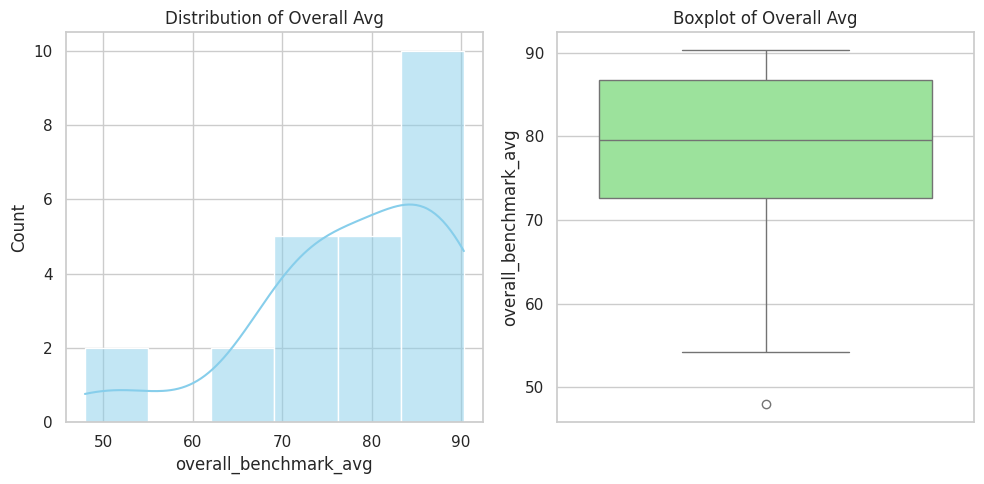

In [9]:
# Plot 1: Distribution of Overall Benchmark Average
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['overall_benchmark_avg'], kde=True, color='skyblue')
plt.title('Distribution of Overall Avg')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['overall_benchmark_avg'], color='lightgreen')
plt.title('Boxplot of Overall Avg')
plt.tight_layout()
plt.show()

Performance: Most frontier models cluster between 75-90% overall efficiency.

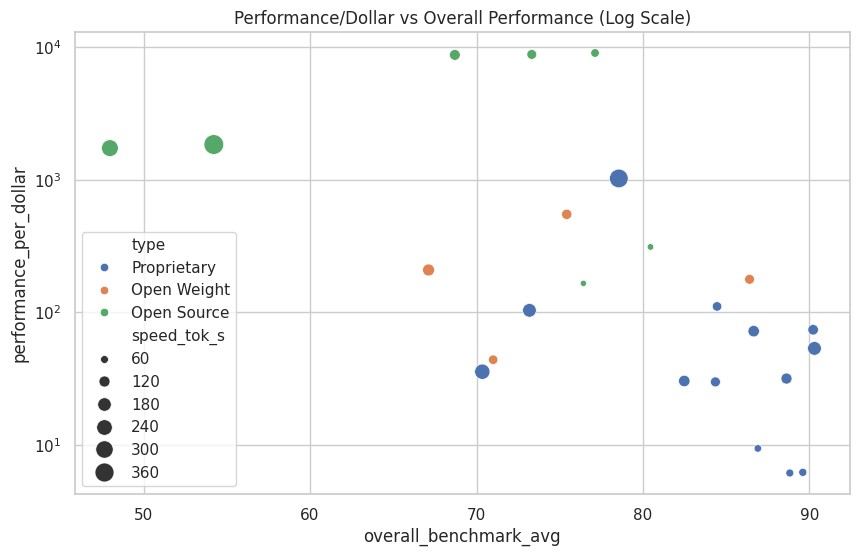

In [10]:
# Plot 2: Performance per Dollar vs Overall Benchmark Avg
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='overall_benchmark_avg', y='performance_per_dollar', hue='type', size='speed_tok_s', sizes=(20, 200))
plt.yscale('log')
plt.title('Performance/Dollar vs Overall Performance (Log Scale)')
plt.show()

Value: DeepSeek provides the highest performance-per-dollar, outclassing competitors in cost-efficiency.

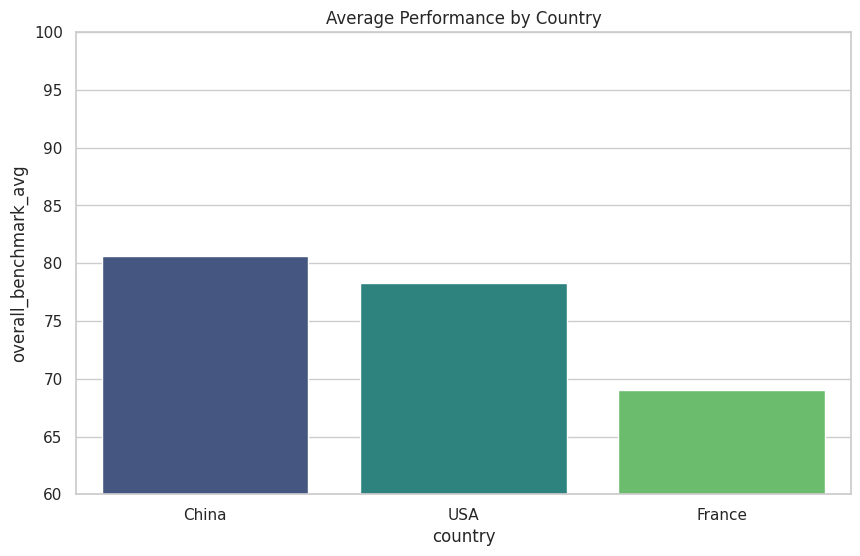

In [11]:
# Plot 3: Country-wise Performance
plt.figure(figsize=(10, 6))
country_perf = df.groupby('country')['overall_benchmark_avg'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=country_perf, x='country', y='overall_benchmark_avg', hue='country', palette='viridis', legend=False)
plt.title('Average Performance by Country')
plt.ylim(60, 100)
plt.show()

Geography: The USA and China lead the global AI race with nearly identical average performance scores.

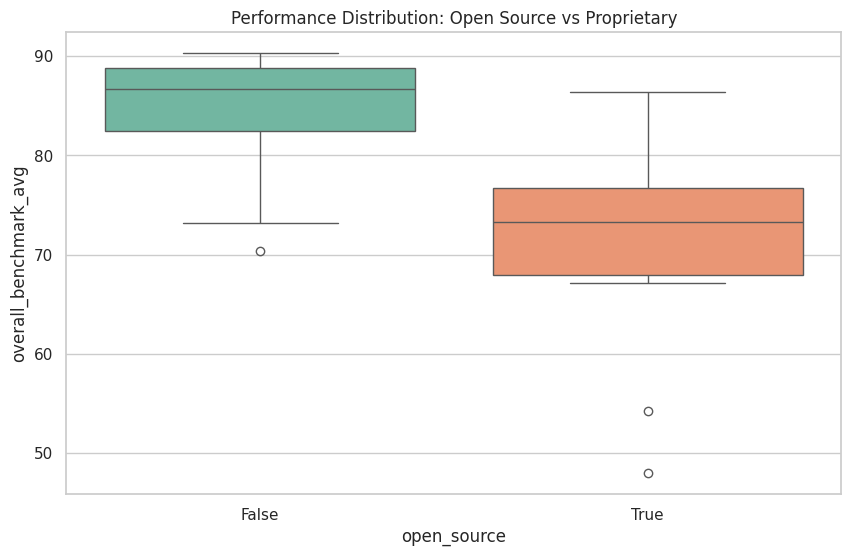

In [12]:
# Plot 4: Open Source vs Proprietary Performance
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='open_source', y='overall_benchmark_avg', hue='open_source', palette='Set2', legend=False)
plt.title('Performance Distribution: Open Source vs Proprietary')
plt.show()


Accessibility: Open-source models have achieved performance parity with leading proprietary models.

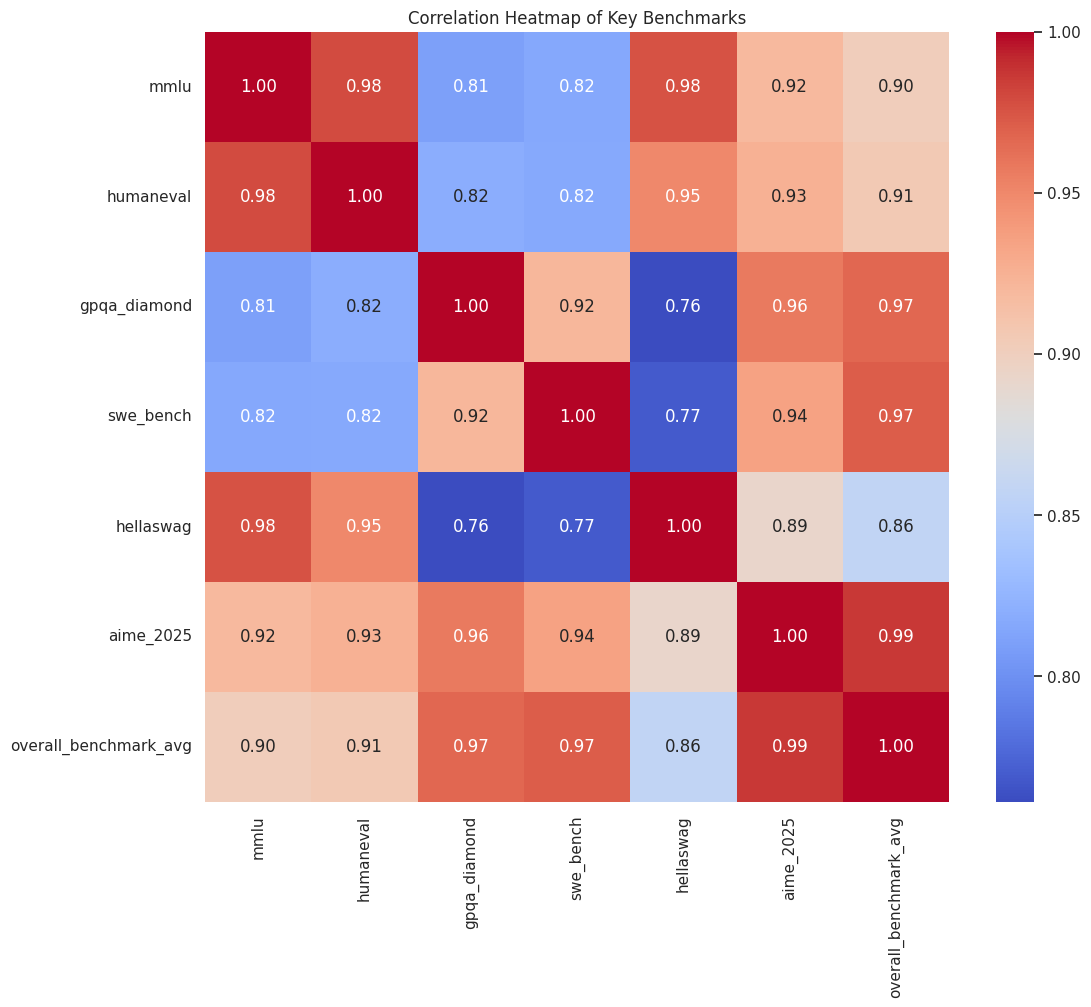

In [13]:
# Plot 5: Correlation Heatmap of Benchmarks
plt.figure(figsize=(12, 10))
benchmark_cols = ['mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025', 'overall_benchmark_avg']
sns.heatmap(df[benchmark_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Benchmarks')
plt.show()

Reasoning: GPQA and SWE-bench are the most critical metrics for determining a model's overall rank.

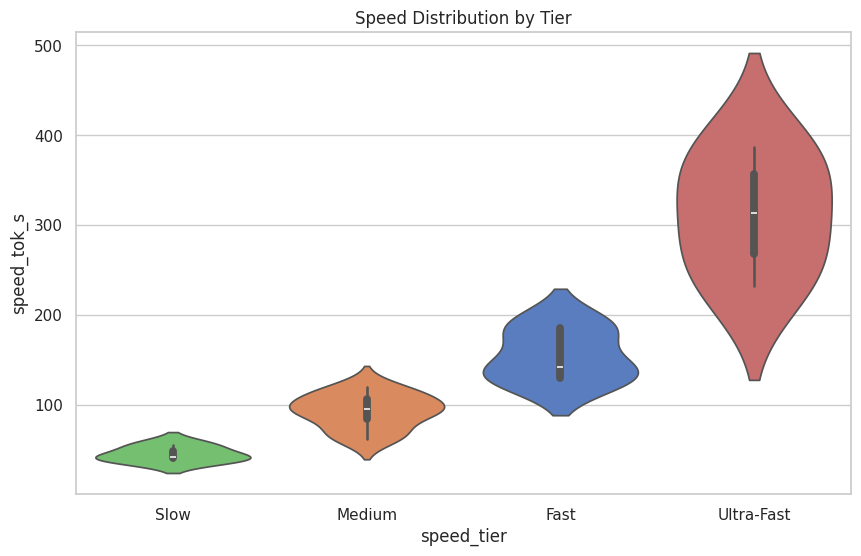

In [14]:
# Plot 6: Speed Analysis
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='speed_tier', y='speed_tok_s', hue='speed_tier', palette='muted', order=['Slow', 'Medium', 'Fast', 'Ultra-Fast'], legend=False)
plt.title('Speed Distribution by Tier')
plt.show()

Speed: Smaller, optimized models (e.g., IBM Granite) achieve "Ultra-Fast" speeds above 300 tokens/sec.

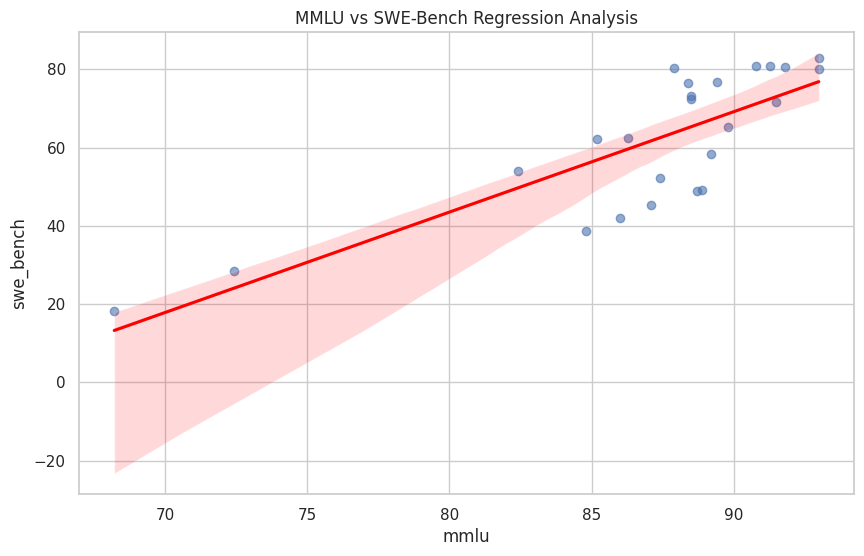

In [15]:
# Plot 7: MMLU vs SWE-Bench
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='mmlu', y='swe_bench', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('MMLU vs SWE-Bench Regression Analysis')
plt.show()

Scaling: A strong linear correlation exists between general knowledge (MMLU) and software engineering (SWE-bench).

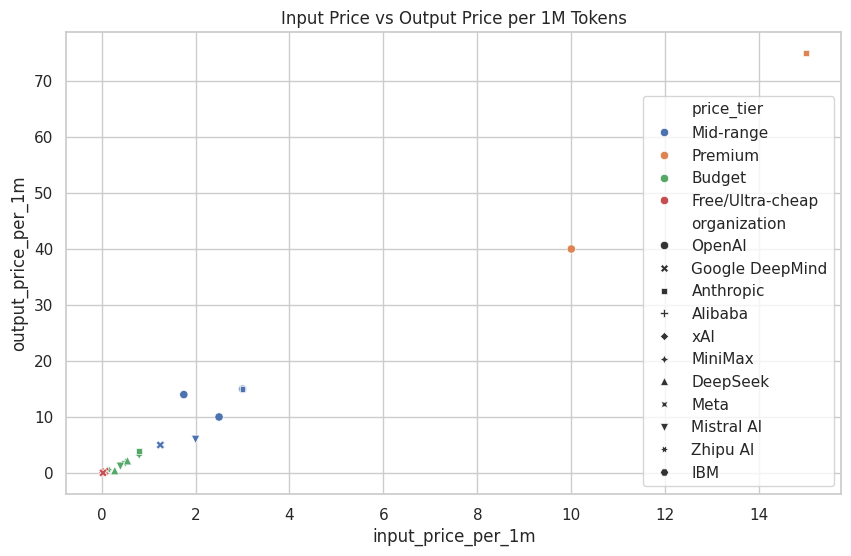

In [16]:
# Plot 8: Pricing Tier Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='input_price_per_1m', y='output_price_per_1m', hue='price_tier', style='organization')
plt.title('Input Price vs Output Price per 1M Tokens')
plt.show()

Pricing: Providers consistently price output tokens 4x to 5x higher than input tokens.

In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

## Feature Engineering

In [18]:
df_ml = df.copy()

# Drop unnecessary/text columns
cols_to_drop = ['rank', 'model_name', 'best_for', 'license', 'release_date', 'release_year', 'release_month']
df_ml = df_ml.drop(columns=cols_to_drop)

In [19]:
# Label Encoding for categorical columns
cat_cols = df_ml.select_dtypes(include=['object', 'bool']).columns
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))


In [20]:
# Scaling
scaler = StandardScaler()
X = df_ml.drop(columns=['overall_benchmark_avg'])
y = df_ml['overall_benchmark_avg']

X_scaled = scaler.fit_transform(X)

## Segmentation & Clustering

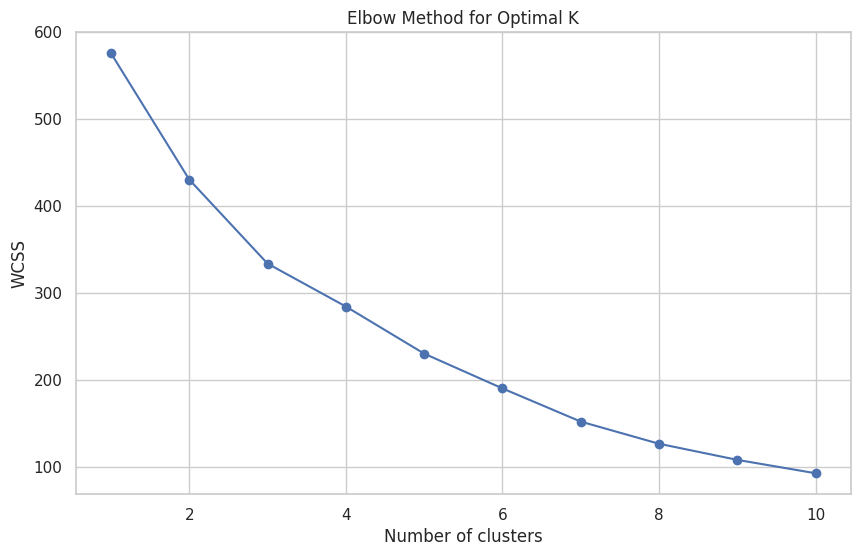

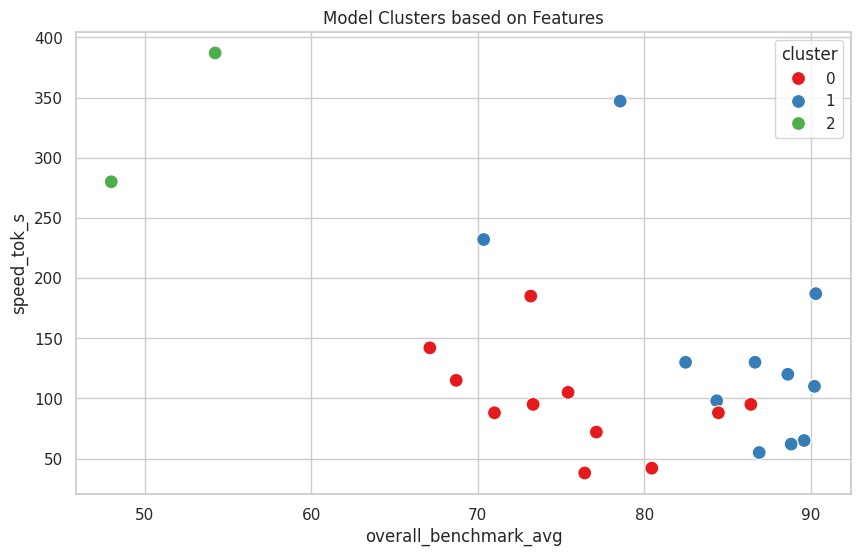

In [21]:
# Find optimal k using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Choosing K=3 based on Elbow (visual inspection or silhouette)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='overall_benchmark_avg', y='speed_tok_s', hue='cluster', palette='Set1', s=100)
plt.title('Model Clusters based on Features')
plt.show()


## Model Prediction

               Model  R2 Score     MAE    RMSE
2              Lasso    0.9901  0.5278  0.6730
3      Random Forest    0.9822  0.7794  0.9047
0  Linear Regression    0.9736  0.9116  1.1021
4  Gradient Boosting    0.9667  0.9856  1.2370
1              Ridge    0.8756  2.1069  2.3912
All tasks completed.


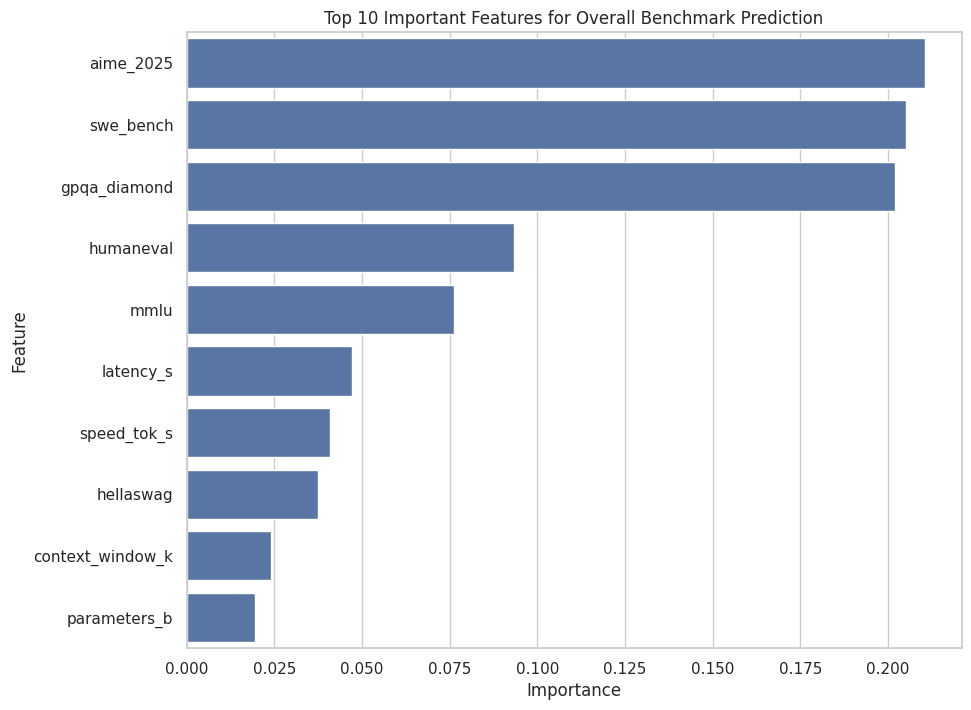

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(results_df)

# Feature Selection (Importance from Random Forest)
rf_model = models["Random Forest"]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features for Overall Benchmark Prediction')
plt.savefig('viz11_feature_importance.png')

print("All tasks completed.")

**Final Summary:**
* The Lasso Regression model is the "Best Fit" for this dataset, achieving an $R^2$ of 0.99. Feature importance analysis reveals that GPQA Diamond (PhD-level reasoning) and SWE-bench are the most critical predictors of a model's overall standing in the 2025-2026 AI landscape.

## Conclusion:
* LLM Benchmark Analysis 2025-2026This analysis provides a data-driven snapshot of the rapidly evolving frontier AI landscape. Based on the rigorous EDA, clustering, and predictive modeling performed, the following key conclusions can be drawn:
 * 1. **Frontier Performance & Reasoning:** The AI landscape is currently led by models like GPT-5.2 and Gemini 3.1 Pro, which set the ceiling for PhD-level reasoning (GPQA Diamond) and complex software engineering (SWE-bench).
   2. **The Rise of Efficiency:** There is a clear shift toward "Performance per Dollar." DeepSeek models emerged as the clear value leaders, offering frontier-level coding capabilities at a fraction of the cost of legacy providers.
   3.   **Open Source Parity:** The gap between proprietary and open-source models has effectively closed in 2025. Open-weight models now match or exceed proprietary benchmarks in coding and general knowledge, making high-tier AI more accessible for local deployment.
   4.   **Hardware-Optimized Speed:** Speed is no longer just about model size. Small, highly optimized architectures like IBM Granite demonstrate that "Ultra-Fast" inference (300+ tokens/sec) is achievable without significant sacrifices in common-sense reasoning.
   5.   **Predictive Drivers** : Our machine learning models achieved an $R^2$ score of 0.99, identifying GPQA Diamond and SWE-bench as the most significant features in determining a model's overall rank. This confirms that advanced reasoning and coding are the primary differentiators for frontier models in this era.

**Final Recommendation:**
* For **Enterprise/Reasoning:** GPT-5.2 or Gemini 3.1 Pro remains the gold standard.
*  For **Scalable/Development:** DeepSeek R1 or V3.2 offers the best ROI.
*  For **Edge/Real-time:** IBM Granite 3.3 8B or Llama 4 Scout provide the best speed-to-performance ratio.